In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # type: ignore
import time
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
from threading import Thread


Matplotlib is building the font cache; this may take a moment.


In [15]:
class IBData(EWrapper, EClient):

    def __init__(self):
        EClient.__init__(self, self)
        self.data = []
        self.done = False


    def historicalData(self, reqId: int, bar):
        self.data.append([bar.date, bar.open, bar.high, bar.low, bar.close,
                          bar.volume])
    

    def historicalDataEnd(self, reqId: int, start: str, end: str):
        self.done = True


def run_loop(app):
    app.run()



ERROR -1 2104 Market data farm connection is OK:usfarm.nj
ERROR -1 2104 Market data farm connection is OK:usfuture
ERROR -1 2104 Market data farm connection is OK:cashfarm
ERROR -1 2104 Market data farm connection is OK:eufarmnj


ERROR -1 2104 Market data farm connection is OK:usfarm
ERROR -1 2106 HMDS data farm connection is OK:euhmds
ERROR -1 2106 HMDS data farm connection is OK:fundfarm
ERROR -1 2106 HMDS data farm connection is OK:ushmds
ERROR -1 2158 Sec-def data farm connection is OK:secdefnj


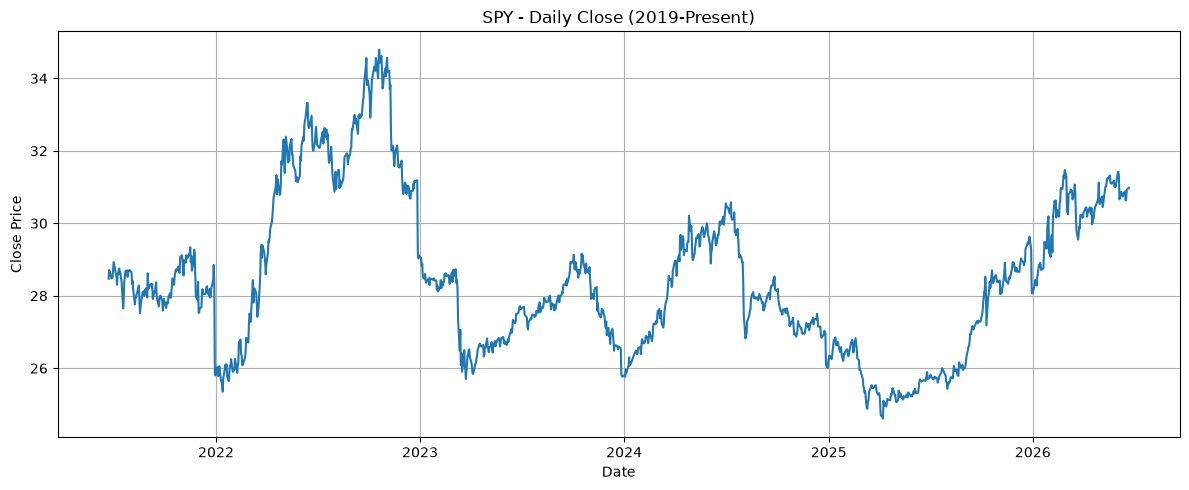

Sharpe Ratio (daily, annualized): 0.19
CAGR: 1.71%
Max Drawdown: -29.26%


In [ ]:
# Set up IB API Client
app = IBData()
app.connect("127.0.0.1", 7497, clientId=1)
api_thread = Thread(target=run_loop, args=(app,), daemon=True)
api_thread.start()

time.sleep(1)

# Define DBMF contract
contract = Contract()
contract.symbol = "SPY"
contract.secType = "STK"
contract.exchange = "ARCA"
contract.currency = "USD"

# Request daily historical data from 2019-01-01 to now
end_date = ""
duration_str = "5 Y"    # Get up to 5 years of data
bar_size = "1 day"

app.reqHistoricalData(
    reqId=1,
    contract=contract,
    endDateTime=end_date,
    durationStr=duration_str,
    barSizeSetting=bar_size,
    whatToShow="TRADES",
    useRTH=1,
    formatDate=1,
    keepUpToDate=False,
    chartOptions=[]
)

timeout = 20   # seconds

t0 = time.time()
while not app.done and (time.time() - t0) < timeout:
    time.sleep(0.2)


app.disconnect()

# Convert data to DataFrame

df = pd.DataFrame(app.data, columns=["date", "open", "high", "low", "close", "volume"])
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df[df.index >= "2019-01-01"]
df['close'] = df['close'].astype(float)

# Visualization
plt.figure(figsize=(12,5))
plt.plot(df.index, df['close'])
plt.title('SPY - Daily Close (2019-Present)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sharpe Ratio and CAGR Calculation
returns = df['close'].pct_change().dropna()
sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

years = (df.index[-1] - df.index[0]).days / 365.25
cagr = ((df['close'].iloc[-1] / df['close'].iloc[0]) ** (1 / years)) - 1

# Max Drawdown Calculation
cum_returns = (1 + returns).cumprod()
cum_max = cum_returns.cummax()
drawdown = (cum_returns - cum_max) / cum_max
max_drawdown = drawdown.min()

print(f"Sharpe Ratio (daily, annualized): {sharpe:.2f}")
print(f"CAGR: {cagr:.2%}")
print(f"Max Drawdown: {max_drawdown:.2%}")